#**Imports**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Mount Drive and Load Data**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load in data
fpath = "/content/drive/MyDrive/AXSOSACADEMY/02-IntroML/Week06/Data/insurance.csv"
df = pd.read_csv(fpath)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#**Define Existing plot_categorical_vs_target Function**

In [ ]:
# Previously defined function
def plot_numeric_vs_target(df, x, y='SalePrice', figsize=(6,4), **kwargs): # kwargs for sns.regplot
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]
  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})")
  # Make sure the plot is shown before the print statement
  plt.show()
  return fig, ax

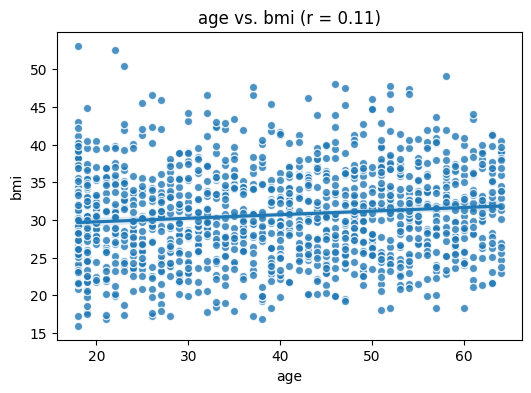

In [ ]:
# Call function to explore age when bmi is the target
plot_numeric_vs_target(df, "age",'bmi');

#**Developing Visualization for a Categorical Target**

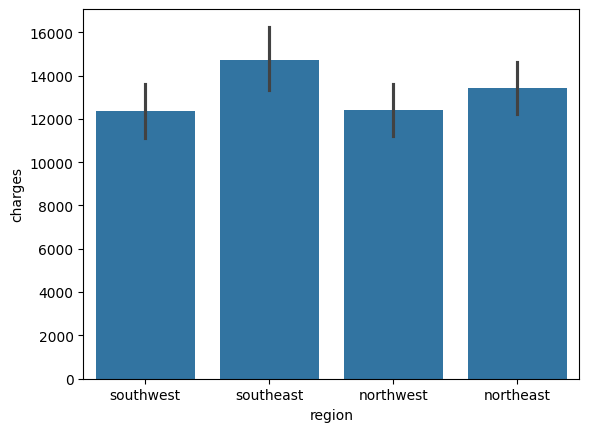

In [ ]:
# Test out a Seaborn barplot
sns.barplot(data=df, x='region', y='charges');

**Mean = يتأثر بالقيم الكبيرة**

**Median = أدق لما في outliers**

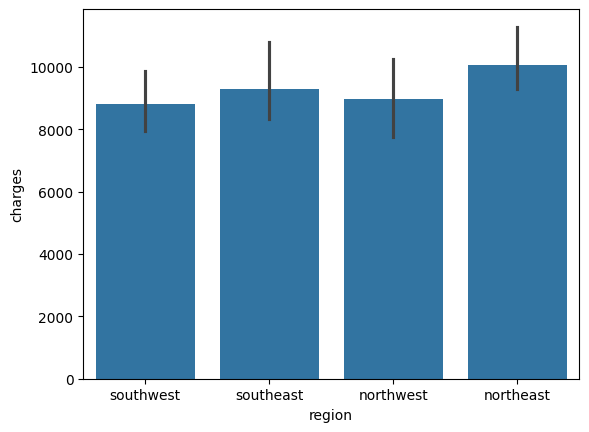

In [ ]:
# Changing the estimator to median
sns.barplot(data=df, x='region', y='charges',estimator='median');

#**Errorbars**

**Error bars = توضح مدى تشتت البيانات**

**ci = ثقة بالنتيجة**

**se = دقة المتوسط**


**SE صغير → المتوسط ثابت ✔️**

**SE كبير → المتوسط يتغير كثير ❌**

#**Sorting By Group Value**

In [ ]:
# Define needed variables
target = 'region'
X_feature ='charges'
estimator='mean'
# Group by the estimator value
group_values = df.groupby(target)[X_feature].agg(estimator)
# Sort by the value
group_values = group_values.sort_values(ascending=False)
# Display
group_values

,charges
region,
southeast,14735.411438
northeast,13406.384516
northwest,12417.575374
southwest,12346.937377


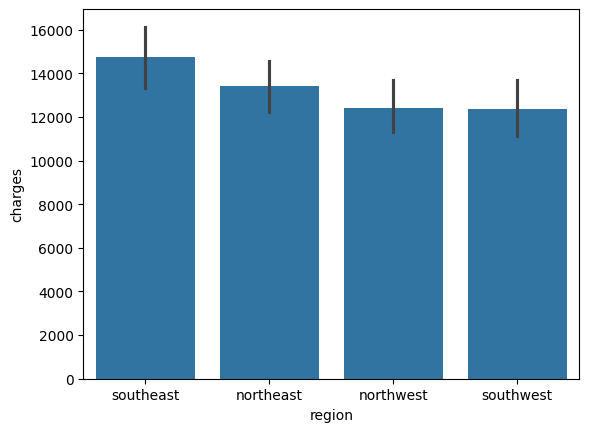

In [ ]:
# Testing the plot with sorted values
ax = sns.barplot(data=df, x='region', y= 'charges', estimator='mean',
            order=group_values.index)

##**Updating the plot_numeric_vs_target Function**

In [ ]:
# Updating the function
def plot_numeric_vs_target(df, x, y, figsize=(6,4),
                           target_type='reg', estimator='mean',
                           errorbar='ci',sorted=False,ascending=False,
                           **kwargs): # kwargs for sns.regplot

  nulls = df[[x,y]].isna().sum()
  if nulls.sum()>0:
    print(f"- Excluding {nulls.sum()} NaN's")
    # print(nulls)
    temp_df = df.dropna(subset=[x,y,])
  else:
    temp_df = df
  # Create the figure
  fig, ax = plt.subplots(figsize=figsize)

  # REGRESSION-TARGET PLOT
  if 'reg' in target_type:
    # Calculate the correlation
    corr = df[[x,y]].corr().round(2)
    r = corr.loc[x,y]
    # Plot the data
    scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
    sns.regplot(data=temp_df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
    ## Add the title with the correlation
    ax.set_title(f"{x} vs. {y} (r = {r})")

  # CLASSIFICATION-TARGET PLOT
  elif 'class' in target_type:

    # Sort the groups by median/mean
    if sorted == True:

      if estimator == 'median':
        group_vals = temp_df.groupby(y)[x].median()
      elif estimator =='mean':
        group_vals = temp_df.groupby(y)[x].mean()

      ## Sort values
      group_vals = group_vals.sort_values(ascending=ascending)
      order = group_vals.index

    else:
      # Set order to None if not calcualted
      order = None


    # Left Subplot (barplot)
    sns.barplot(data=temp_df, x=y, y=x, order=order,  estimator=estimator,
                errorbar=errorbar, ax=ax, **kwargs)

    # Add title
    ax.set_title(f"{x} vs. {y}")

    # rotate xaxis labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


  # Final Adjustments & return
  fig.tight_layout()
  fig.show()
  return fig, ax

**target_type (Default: 'reg'):**

يحدد نوع المهمة؛ إذا كانت reg (Regression) يرسم Scatter plot، وإذا كانت class (Classification) يرسم Barplot.


**estimator (Default: 'mean'):**

 يحدد العملية الحسابية التي سيتم الرسم بناءً عليها (المتوسط الحسابي mean أو الوسيط median).

 **errorbar (Default: 'ci'):**

  يتحكم في شكل خطأ القياس الظاهر فوق الأعمدة، مثل ci لمجال الثقة أو se للخطأ المعياري.

  **sorted (Default: False):**
  
   قيمة بولية (True/False) تحدد ما إذا كنت تريد ترتيب الأعمدة بناءً على قيم الـ estimator أم لا.

  **التحليل البصري (Visualization)**

تم استخدام sns.barplot مع تمرير معامل order الذي يأخذ ترتيبه من عملية groupby داخلية، مما يجعل الرسم أكثر وضوحاً عند المقارنة بين الفئات (Regions).

 **التصفية للفحص (Deep Dive)**

تمت إضافة جمل شرطية (If statements) داخل الفانكشن لتقرر: "هل الهدف تصنيفي؟ إذن استخدم الترتيب المخصص"، وهذا يزيد من مرونة الكود لإعادة الاستخدام في مشاريع مختلفة.

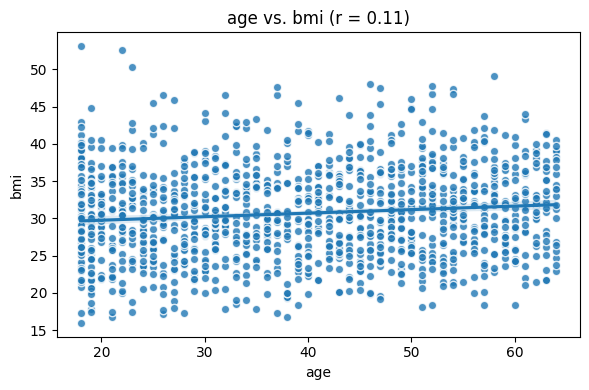

In [ ]:
# plot original regression task plot
plot_numeric_vs_target(df,'age','bmi');

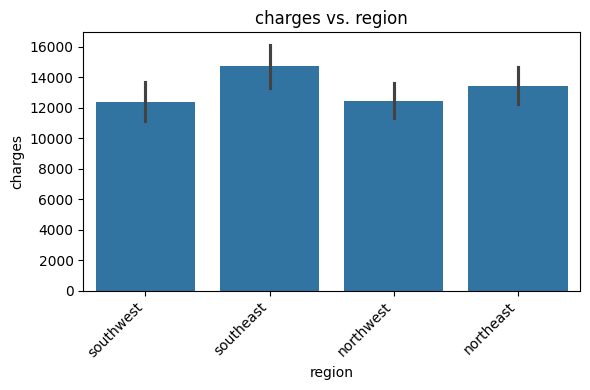

In [ ]:
# Plot target_type='class'
plot_numeric_vs_target(df,'charges','region', target_type='class');

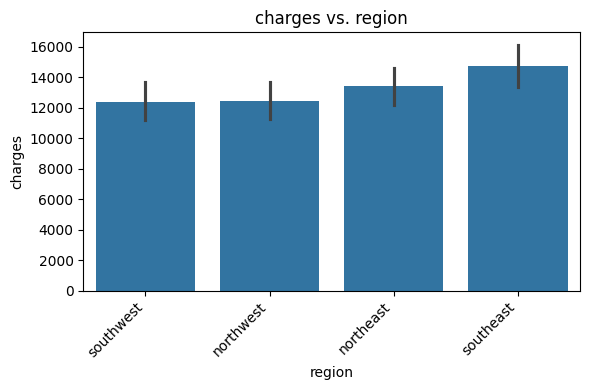

In [ ]:
# Add sorting the target's categories
plot_numeric_vs_target(df,'charges','region', target_type='class', sorted=True, ascending=True);

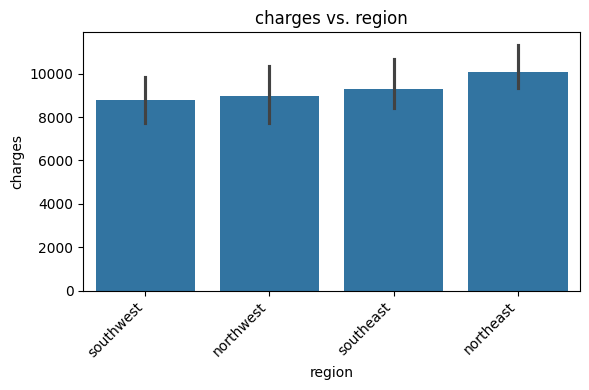

In [ ]:
# Change the estimator to median
plot_numeric_vs_target(df,'charges','region', target_type='class',estimator='median',
                       sorted=True, ascending=True);

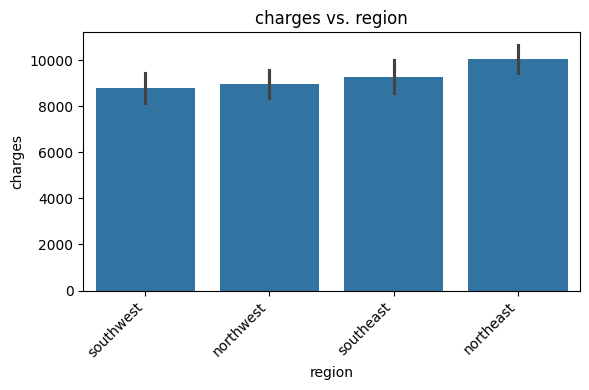

In [ ]:
# Change the errorbar to "se"
plot_numeric_vs_target(df,'charges','region', target_type='class',estimator='median',
                       sorted=True, ascending=True, errorbar='se');